# Conway's Game of Life

## Setup

The first step of running a Julia program is to load the external libraries one will be using. We do this with a `using` statement.

In [1]:
using AlgebraicABMs, Catlab, AlgebraicRewriting, Random, Test
ENV["JULIA_DEBUG"] = "AlgebraicABMs";
Random.seed!(100);

## Schema

Defining an schema is stating what data is required to specify a state of the
simulation at some point in time. In AlgebraicJulia, this is done via declaring
a `Presentation`, i.e. a database schema. Objects (`Ob`, or tables) are types of
entities. Homs (`Hom`, or foreign keys) are functional relationships between the
aforementioned entities. AttrTypes are placeholders for Julia types, which are
assigned to objects via attributes (`Attr`).

The schema below *extends* the schema for symmetric graphs, which consists in
two tables (`E` and `V`, for edges and vertices), a hom `inv` which pairs each 
edge with its symmetric dual edge, and homs (`src`, `tgt`) which
relate the edges to the vertices. We consider each vertex to be a cell in the
Game of Life. This is a generalization of the game, since it is not enforced
that every cell has eight neighbors. However the example we run at the end will
be a regular grid of vertices. 

Everything in the `@present` presentation below simply adds to the schema of
symmetric graphs, indicated by the subtype operator `<: SchSymmetricGraph`. We
need one more piece of information to specify a state of the world in the game
of life: which cells are alive? There are a few ways one could distinguish the
living cells from the dead ones. Here, we add a new table, `Life` which can be
though of as a set of "life tokens". A function, `live`, assigns each such token
to a cell, designating it to be alive. Thus the subset of living cells is the
image of the `live` function. 

To summarize, a state of the world in the Game of Life is a set of cells (i.e.
vertices), a set of edges (with `src`/`tgt` functions) which encode which cells 
are near each other, and a distinguished subset of cells given by the `live`
function which marks which cells are alive. This information is summarized in 
the following graphical depiction of the schema.

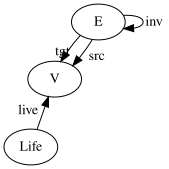

In [2]:
@present SchLifeGraph <: SchSymmetricGraph begin 
  Life::Ob
  live::Hom(Life,V)
end

to_graphviz(SchLifeGraph) # visualize the schema

If `SchLifeGraph` is the piece of data which describes what it means to be a
world state, we need a Julia datatype whose values are world staets.

The `@acset_type` macro takes the specification of a datatype (i.e. a
schema), and it generates an efficient Julia datatype, which is essentially the
type of in-memory databases which have their schema given by `SchLifeGraph`. 

This line defines `LifeState` to be this new Julia type, and futhermore it
states that it satisfies the `AbstractSymmetricGraph` interface: Catlab already
has a lot of generic code to work with SymmetricGraph-like things, so now we are
free to use it with LifeState.

In [3]:
@acset_type LifeState(SchLifeGraph) <: AbstractSymmetricGraph;

Before we start defining the dynamics of our Game of Life, it'll be helpful to
visualize states of the world. One thing that `SchLifeGraph` did not have was  
(x,y) coordinate information. Because we were representing proximity of vertices
by the prescence or absence of an edge connecting them, these coordinates are
irrelevant to the model dynamics. 

However, the coordinates are useful for visualization, so the below code creates
a new schema which extends the previous one to add coordinates.

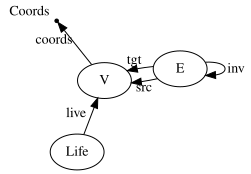

In [4]:
@present SchLifeCoords <: SchLifeGraph begin
  Coords::AttrType
  coords::Attr(V, Coords)
end

to_graphviz(SchLifeCoords)

Likewise for this new schema, we need to use `@acset_type` to turn the
description of the required data of a world state (the schema) into an actual
Julia datatype. One difference here is that there is now an attribute present,
which means we need to indicate what Julia type it should be. 

Our new Julia type is `LifeStateCoords`, and we pick `Tuple{Int,Int}` as our
representation of (x,y) coordinates.

In [5]:
@acset_type LifeStateCoords(SchLifeCoords){Tuple{Int,Int}} <: AbstractSymmetricGraph;

The following (hidden) code visualizes LifeStates and uses coordinates 
if the input is a `LifeStateCoords`, but otherwise it places the vertices in 
an arbitrary location.

In [6]:
function view_life(X::Union{LifeState, LifeStateCoords}, pth=tempname())
  pg = PropertyGraph{Any}(; prog="neato", graph=Dict(),
    node=Dict(:shape => "circle", :style => "filled", :margin => "0"), 
    edge=Dict(:dir => "none", :minlen => "1")) 
  add_vertices!(pg, nparts(X, :V))
  for v in vertices(X)
    is_alive = isempty(incident(X, v, :live))
    set_vprop!(pg, v, :fillcolor, is_alive ? "red" : "green")
    if X isa LifeStateCoords
      x, y = X[v, :coords]
      set_vprop!(pg, v, :pos, "$x,$(y)!")
    end 
  end 
  for e in filter(e -> X[e, :inv] > e, edges(X)) 
    add_edge!(pg, X[e, :src], X[e, :tgt]) 
  end 
  G = to_graphviz(pg) 
  open(pth, "w") do io 
    show(io, "image/svg+xml", G) 
  end 
  return G 
end; 

This (hidden) helper function creates an ordinary, square grid and initializes cells as
alive or dead via a boolean-valued input matrix. Like above, one does not need
to understand this in order to understand the Game of Life model - it's just a 
convenient way to generate some initial states to run the model on.

In [7]:
function make_grid(curr::AbstractMatrix)
  n, m = size(curr) 
  n == m || error("Must be square") 
  X, coords = LifeStateCoords(), Dict() 
  for j in 1:n, i in 1:n 
    coords[i=>j] = add_vertex!(X; coords=(i, j)) 
    Bool(curr[i, j]) && add_part!(X, :Life, live=coords[i=>j]) 
  end 
  for i in 1:n, j in 1:n 
    i < n && add_edge!(X, coords[i=>j], coords[i+1=>j]) 
    j < n && add_edge!(X, coords[i=>j], coords[i=>j+1]) 
    i < n && j < n && add_edge!(X, coords[i=>j], coords[i+1=>j+1]) 
    i < n && j > 1 && add_edge!(X, coords[i=>j], coords[i+1=>j-1]) 
  end 
  return X 
end; 

Another helper function, which creates a game state on a square n × n grid.
If the keyword `random` is `true` (which it is, by default), then cells have a
50% chance of being alive.

Note: red color means that a cell is not in the image of the `live` function.


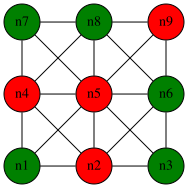

In [8]:
make_grid(n::Int, random=true) = 
  make_grid((random ? rand : zeros)(Bool, (n, n)));

view_life(make_grid(3)) # For example, visualize a random 3x3 grid

We've now constructed two schemas and two datatypes. No doubt they are related
to each other, and AlgebraicJulia gives us the ability to take advantage of that
relationship in order to automatically values of `LifeStateCoords` into values
of `LifeState` (it does this is the obvious way: it throws away the coordinate
information). More interestingly, it gives us a way of converting a `LifeState`
into a `LifeStateCoords`: we give "generic" coordinates to each of the vertices.

If we call `AddCoords` on something built out of `LifeState` instances, it will 
make the corresponding thing built out of `LifeStateCoords` instances. 


In [9]:
AddCoords = Migrate(SchLifeGraph, LifeState, SchLifeCoords, LifeStateCoords; delta=false);

## Initial State

With our `make_grid` function, it's easy to create an initial state.

We'll use this world-state, called `G` throughout the model-building process to confirm our model building blocks work the way they're supposed to work. 

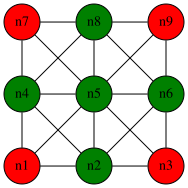

In [10]:
G = make_grid([0 1 0;
               1 1 1;
               0 1 0])
view_life(G)

## Building Blocks for the Game of Life Model

We are now ready to build our model, which will have three rules: 
underpopulation, overpopulation, and birth. When we write these rules down, it 
will be very succinct due to the hard work of this section: laying out the 
building blocks. 

Our first building block is an instance of `LifeState`. Now, 
we don't want to think of this as a particular state of the game of life, but 
rather we want to think of it as a *pattern* for which we could look for 
*matches* inside a real game state.

This pattern is very simple: it consists of a single vertex. A *match* for 
this pattern in some world state `X` is just a choice of a vertex in `X`. The 
matched vertex need not be dead just because our pattern vertex is not marked 
as alive. So the meaning of `Cell` is "a dead or alive cell", despite the fact 
that, when we visualize it, it shows up as red (because it hasn't been marked 
explicitly to be alive).

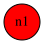

In [11]:
const Cell = LifeState(1) # this means: a graph with one vertex, nothing else

view_life(Cell) # red color means this cell is not in image of `life` function.

Let's confirm that this works. Our fancy word for "pattern match" is
"homomorphism" ("morphism", for short). To look for morphisms from `Cell`
into `G` is to ask "find me all the cells!". The Catlab function `homomorphisms`
exhaustively finds all such answers to a query like this. When we run it below,
we ought see there are 9 answers to this query, as there are 9 vertices in the 3
× 3 grid.

In [12]:
length(homomorphisms(AddCoords(Cell), G))

9

Our next building block is also a `LifeState` instance that we think of as a pattern. It is a cell but, furthermore, it is a cell which has been marked as alive. This means it consists in one vertex, one 'life token', and the function `live` which maps `Life₁` to `V₁`. 

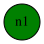

In [13]:
const LiveCell = @acset LifeState begin V=1; Life=1; live=1 end

view_life(LiveCell) # green color means this cell is in image of `life` function

Let's confirm that this works.  If we look for morphisms from `LiveCell` into `G`, meaning "find me all the live cells!", we will see there are 5 answers to this query

In [14]:
length(homomorphisms(AddCoords(LiveCell), G))

5

Now we will see our first morphism that is not between some pattern and some
world state but, rather, is *between* our the two previous patterns. A
morphism from `Cell` is an answer to the query "give me a Cell!" and there
is exactly one possible answer to that query in `LiveCell`, thus we can use
`homomorphism`, which returns an arbitrary morphism from the set of
morphisms computed by `homomorphisms`.

`to_life` is an important morphism to understand as it is the fundamental 
"engine" of the Game of Life. When read 'forwards', it expresses the idea of 
taking a vertex and adding a Life token to it. When read 'backwards', it 
expresses the idea of removing a Life token from a vertex. This is all we 
actually do when simulating the Game of Life: we toggle cells between being 
marked as alive vs no longer being marked as alive.

In [15]:
const to_life = homomorphism(Cell, LiveCell);

The remaining challenge is to control the circumstances under which we perform
this fundamental action of toggling life status. This is done via a technique
called "Positive (resp. negative) application conditions". An application
condition is a way of embedding a small pattern in a larger pattern (a context)
with the assertion that, for a specific match of the small pattern in a world
state, that this context is required (resp. forbidden) to hold. 

Here the small pattern, the large pattern, and the world state will all be 
`LifeState` instances. And the the 'embedding' of the small pattern into the 
large pattern as well as the match of the small pattern in the world will both
be morphisms between `LifeState` instances. 

The following lines of code provide shorthand names for positive and 
negative applications. The use of the keyword `monic` can be ignored if this 
is your first time looking at AlgebraicJulia code. If not, the keyword indicates
that the morphism (from the larger context to the world state, used to determine
whether the application condition is satisfied) is required to be monic.

In [16]:
PAC(m) = AppCond(m; monic=true) # Positive Application condition
NAC(m) = AppCond(m, false; monic=true); # Negative Application condition

The following line provides a shorthand for constructing the fundamental 
building block of an ABM, which is an `ABMRule`. Such a rule requires a name, an
instance of a rewrite `Rule` object from `AlgebraicRewriting`, as well as a 
timer which indicates the frequency at which the rule fires. All three of our 
rules will fire at every tick in time.

In [17]:
TickRule(name, I_L, I_R; ac) = # Rule which fires on 1.0, 2.0, ...
  ABMRule(name, Rule(I_L, I_R; ac), DiscreteHazard(1));

The context for determining whether the rules of underpopulation,
overpopulation, or birth apply are always framed in terms of "how many living
neighbors do you have?". Thus, it is helpful to have function which creates a
context of `n` living neighbors which we can use with various values of `n`.

Providing a context for a pattern is more than just giving an instance of 
`LifeState`; we also have to say how the pattern relates to the context. So
our pattern here is either a vertex (if `alive=false`) or a vertex marked as 
alive (`alive=true`, which is the default value). This morphism data is 
what allows us to pick out the *center* vertex as the relevant starting point 
when checking if a particular match (which is a choice of a vertex in the 
game state) actually exists with that context of `n` living living neighbors.

When we visualize the result of this function below, we're only visualizing the 
*codomain* of the morphism (i.e. what the morphism is pointing to).

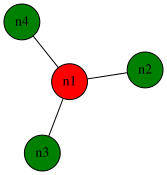

In [18]:
function living_neighbors(n::Int; alive=true)::ACSetTransformation
  X = LifeState(1) 
  alive && add_part!(X, :Life, live=1) 
  for _ in 1:n 
    v = add_part!(X, :V) 
    add_part!(X, :Life, live=v) 
    add_edge!(X, v, 1) 
  end 
  homomorphism(alive ? LiveCell : Cell, X; initial=(V=[1],)) 
end; 

view_life(codom(living_neighbors(3; alive=false)))

## Create Model by Defining Update Rules

We now have our building blocks in place and can build the three rules.

A rewrite rule is given by a pair of morphisms, `L ← I → R`. The first morphism
is 'read backwards' (thought of as deletion), and the second one is 'read
forwards' (thought of as addition). When one's rule does pure addition, the
first morphism is an identity map. Likewise when one's rule does pure deletion,
the second morphism is an identity map. So rules `underpop` and `overpop` will
have their rule given by first `to_life` and then `id(Cell)`, whereas the rule
`birth` will first have `id(Cell)` and then `to_life`. The real interesting part
of these constructions then is their application conditions (given via a 
keyword argument `ac`).

Let's start with underpopulation: a cell dies due to underpopulation if it has
fewer than two living neighbors. So the application condition is a *negative*
application: if we notice a cell has the context of two living neighbors, we 
should **not** apply the `underpop` rule.

In [19]:
underpop = 
  TickRule(:Underpop, to_life, id(Cell); ac=[NAC(living_neighbors(2))]);

A cell dies due to overpopulation if it has over 3 living neighbors. So here our
condition of applying the death rewrite (i.e. reading the morphism `to_life`
backwards) is a *positive* application condition. We cannot kill a cell unless,
furthermore, that cell is in a context where it has (at least) four living
neighbors.

In [20]:
overpop = 
  TickRule(:Overpop, to_life, id(Cell); ac=[PAC(living_neighbors(4))]);

The rule for birth is that one must have a dead cell with exactly three living
neighbors. Our pattern here is simple a vertex, which could match any cell in 
the game state! So we need to use multiple application conditions to make 
sure the cell has at least three neighbors, fewer than four neighbors, and 
doesn't already have a life token. These three constraints are respectively the 
three elements of the list below.

In [21]:
birth = TickRule(:Birth, id(Cell), to_life; 
                 ac=[PAC(living_neighbors(3; alive=false)),
                     NAC(living_neighbors(4; alive=false)),
                     NAC(to_life)]); # this rule does NOT apply if cell is alive

## Create the Model

We can now create the model: an ABM is constituted by its transition rules

In [22]:
GoL = ABM([underpop, overpop, birth]);

We wrote an ABM for `LifeState`, but we want to apply it to `G` as its 
initial state. `G` is not a `LifeState`, but rather a `LifeStateCoords`! 
Luckily, we defined `AddCoords` earlier which knows how to migrate things in 
the language of `LifeState` into the language of `LifeStateCoords`.

In [23]:
GoL_coords = AddCoords(GoL); 

## Check That Our Rules Make Sense

Let's remind ourselves what G looks like

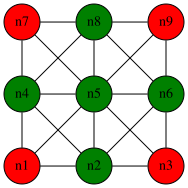

In [24]:
view_life(G)

This code below counts how many matches a rule has, application conditions considered. It returns the coordinates of those matches.

In [25]:
match_coords(f::ACSetTransformation) =  codom(f)[f[:V](1), :coords]
match_coords(rule::ABMRule, X) = match_coords.(get_matches(AddCoords(rule), X));

Let's calculate which cells will die from underpopulation in the first time step: 

In [26]:
match_coords(underpop, G)

Any[]

This is right, there are no living cells which have fewer than two living neighbors.

Now, we see that the center cell dies from overpopulation: 

In [27]:
match_coords(overpop, G)

1-element Vector{Tuple{Int64, Int64}}:
 (2, 2)

Below are the coordinates of the four cells that will come to life:

In [28]:
match_coords(birth, G)

4-element Vector{Tuple{Int64, Int64}}:
 (1, 1)
 (3, 1)
 (1, 3)
 (3, 3)

## Running the ABM

This is easy! Pass in our model and our initial state. We optionally could limit the run via some maximum number of steps or time, but this one will achieve steady state within 3 time steps.

In [ ]:
res = run!(GoL_coords, G);
@test length(res) == 13

## View the Results

We use `view_life` to generate a bunch of images capturing the trajectory.

In [30]:
imgs = view(res, view_life);

The first image is our starting point:

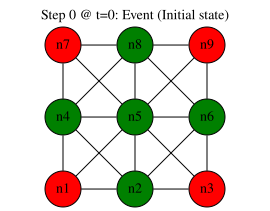

In [31]:
imgs[1]

The next steps (all taking place at `t=1.0`) are the four births and one overpopulation death.

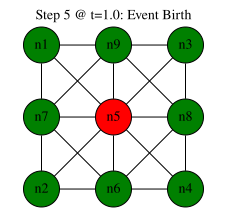

In [32]:
imgs[2]
imgs[3]
imgs[4]
imgs[5]
imgs[6]

At this point, we move to `t=2.0`. There are now four cells which are overpopulated.

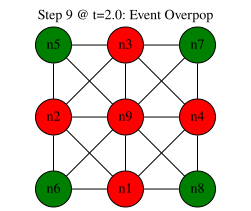

In [33]:
imgs[7]
imgs[8]
imgs[9]
imgs[10]

In the last step, the remaining four living cells perish due to
underpopulation.

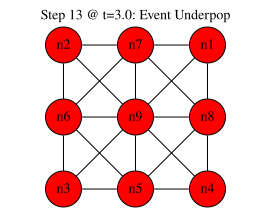

In [34]:
imgs[11]
imgs[12]
imgs[13]
imgs[14]

## Bonus: Stochastic Game of Life

Rather than having all cells update in lockstep, we could change the probability
of firing from a Dirac delta distribution at t=1 to an exponential distribution,
where the expected value is firing at t=1. This means cells will update one at 
a time, as it is almost impossible for two events to occur at the same time.
The change involved for this is simply replacing the `DiscreteHazard` of 
`TickRule` with a `ContinuousHazard`.

In [ ]:
continuous_abm = ABM([ABMRule(r.name, r.rule, ContinuousHazard(1)) for r in GoL_coords.rules]) 
res = run!(continuous_abm, make_grid(4); maxevent=3)
imgs = view(res, view_life);

Here is our starting point:

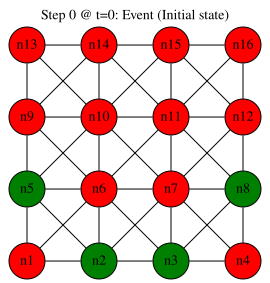

In [36]:
imgs[1]

Let's look at the next few steps:

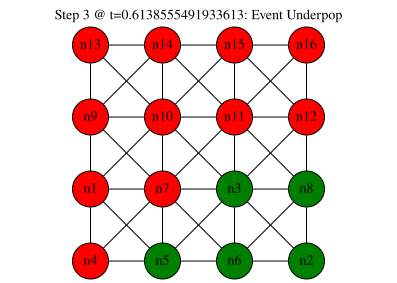

In [37]:
imgs[2]
imgs[3]
imgs[4]